# B.O.S.S. — Test YOLOv8 su recordings

**Pipeline:**
1. Ricerca frame (dataset già estratto su Kaggle)
2. Caricamento `best.pt` + inferenza → frame annotati
3. Distribuzione classi e confidenza
4. Preparazione Ground Truth (`BOSS_recordings.yolov8`)
5. Valutazione quantitativa contro GT (mAP, Precision, Recall)
6. Metriche per classe + grafici
7. Griglia campione frame + dashboard riepilogo
8. Report Markdown leggibile da IA

---
**Output — `/kaggle/working/TEST_OUTPUT/` (ricreata da zero a ogni run):**
- `model_output/` — predizioni sui recordings: frame annotati, `predictions.csv`, distribuzione classi/confidenza, frame campione
- `gt_eval/` — grafici valutazione contro Ground Truth (PR curve, confusion matrix, AP per classe, metriche CSV)
- `comparison/` — dashboard di confronto GT vs output modello
- `markdown/` — report `.md` riepilogativi

---
**Kaggle — dati di input (già estratti sotto `/kaggle/input`):**
- **Dataset** recordings: cartelle `frames` / `frames(1)`
- **Dataset** GT: export Roboflow con `train/test/valid` + `data.yaml`
- **Model**: `best.pt`

In [1]:
# ============================================================
# Cella 1 — Import librerie
# ============================================================
%pip install ultralytics pyyaml tqdm --quiet

import os
import shutil
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import yaml

import matplotlib.pyplot as plt

from tqdm import tqdm
from ultralytics import YOLO

import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [2]:
# ============================================================
# Cella 2 — Configurazione + mappa classi universale
# ============================================================
import torch
import re

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if IS_KAGGLE:
    # ── Kaggle ──────────────────────────────────────────────
    # Modifica questi path in base ai nomi dei tuoi dataset/model su Kaggle.
    KAGGLE_DATA_DIR  = Path("/kaggle/input/datasets/lorenzoverdura")
    KAGGLE_MODEL_DIR = Path("/kaggle/input/models/ultralytics/yolo11/pytorch/default/1")

    BASE_DIR       = Path("/kaggle/input")
    # MODEL_PATH può essere un file .pt OPPURE un nome ultralytics
    # (es. "yolov8s.pt", "yolo11n.pt"), scaricato al volo se Internet è ON.
    MODEL_PATH     = KAGGLE_MODEL_DIR / "yolo11n.pt"
    RECORDINGS_ZIP = KAGGLE_DATA_DIR  / "boss-recordings/recordings"
    GT_ZIP_PATH    = KAGGLE_DATA_DIR  / "boss-recordings1/rf_split"
else:
    # ── Locale ──────────────────────────────────────────────
    BASE_DIR       = Path("/home/lorenzoverdura8/BOSS_CODE")
    MODEL_PATH     = BASE_DIR / "best.pt"
    RECORDINGS_ZIP = BASE_DIR / "recordings.zip"
    GT_ZIP_PATH    = BASE_DIR / "BOSS_recordings.yolov8 (2)/rf_split"

# Directory di lavoro/output (scrivibile in entrambi gli ambienti)
OUTPUT_DIR   = Path("/kaggle/working")
GT_EXTRACTED = OUTPUT_DIR / "ground_truth_boss"   # prep GT (intermedio)

# Struttura unica degli output del test — ricreata da zero a ogni esecuzione
TEST_OUTPUT    = OUTPUT_DIR / "TEST_OUTPUT"
DIR_MODEL_OUT  = TEST_OUTPUT / "model_output"   # output modello sui recordings
DIR_GT_EVAL    = TEST_OUTPUT / "gt_eval"        # grafici valutazione GT
DIR_COMPARISON = TEST_OUTPUT / "comparison"     # confronto GT vs modello
DIR_MARKDOWN   = TEST_OUTPUT / "markdown"       # report .md leggibili da IA

# ── Classi canoniche del progetto B.O.S.S. (da data.yaml della GT) ──────
# Riferimento FISSO: ogni modello viene riportato a questo insieme di classi.
BOSS_CLASSES = [
    "Bench", "Bicycle Rack", "Bike", "Car", "Chair", "Dustbin",
    "Electrical Box", "Electrical Pole", "Manhole", "Motorcycle",
    "Pedestrian crosswalk", "Person", "Plant Pot", "Road", "Stairs",
    "Table", "Teraffic Barrel", "Traffic sign", "Tree", "Truck",
]
NUM_CLASSES = len(BOSS_CLASSES)

# ── Mappa universale: sinonimi → classe BOSS canonica ───────────────────
# Permette il match con QUALSIASI modello (COCO, custom, ecc.) per nome.
# Chiave = nome BOSS canonico; valore = lista di alias (case/spazi-insensitive).
BOSS_ALIASES = {
    "Bench":                ["bench"],
    "Bicycle Rack":         ["bicycle rack", "bike rack", "cycle rack"],
    "Bike":                 ["bike", "bicycle", "cycle"],
    "Car":                  ["car", "automobile"],
    "Chair":                ["chair"],
    "Dustbin":              ["dustbin", "bin", "trash can", "trashcan", "garbage can", "waste bin", "trash"],
    "Electrical Box":       ["electrical box", "electric box", "junction box", "utility box"],
    "Electrical Pole":      ["electrical pole", "electric pole", "utility pole", "power pole", "pole"],
    "Manhole":              ["manhole", "manhole cover"],
    "Motorcycle":           ["motorcycle", "motorbike", "motor bike"],
    "Pedestrian crosswalk": ["pedestrian crosswalk", "crosswalk", "cross walk", "zebra crossing", "pedestrian crossing"],
    "Person":               ["person", "pedestrian", "people", "human"],
    "Plant Pot":            ["plant pot", "potted plant", "pot plant", "flower pot", "flowerpot", "planter"],
    "Road":                 ["road", "street", "roadway"],
    "Stairs":               ["stairs", "staircase", "steps", "stair"],
    "Table":                ["table", "dining table", "desk"],
    "Teraffic Barrel":      ["teraffic barrel", "traffic barrel", "barrel", "traffic drum", "construction barrel"],
    "Traffic sign":         ["traffic sign", "road sign", "street sign", "stop sign", "traffic signal"],
    "Tree":                 ["tree"],
    "Truck":                ["truck", "lorry"],
}

def normalize_name(name):
    """Minuscolo, trim, separatori/spazi uniformati per match robusto."""
    return re.sub(r"[\s_\-]+", " ", str(name).strip().lower())

# alias normalizzato → nome BOSS canonico
ALIAS_TO_BOSS = {}
for _boss in BOSS_CLASSES:
    ALIAS_TO_BOSS[normalize_name(_boss)] = _boss
    for _alias in BOSS_ALIASES.get(_boss, []):
        ALIAS_TO_BOSS[normalize_name(_alias)] = _boss

def resolve_to_boss(name):
    """Nome classe arbitrario → nome BOSS canonico (o None se non mappabile)."""
    return ALIAS_TO_BOSS.get(normalize_name(name))

def build_model_to_boss(model_names):
    """model.names ({id: nome}) → dict {model_id: boss_id} per le classi mappabili."""
    mapping = {}
    for mid, mname in model_names.items():
        boss = resolve_to_boss(mname)
        if boss is not None:
            mapping[int(mid)] = BOSS_CLASSES.index(boss)
    return mapping

IMG_SIZE       = 640
# 0.25 allineata a CONF_THRESHOLD_TRAIN; la val (mAP) usa conf=0.001 — vedi Cella 7.
CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.45
DEVICE         = "0,1" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GT_EXTRACTED.mkdir(parents=True, exist_ok=True)

# Ricrea da zero TEST_OUTPUT/ e le sue sotto-cartelle
if TEST_OUTPUT.exists():
    shutil.rmtree(TEST_OUTPUT)
for d in (DIR_MODEL_OUT, DIR_GT_EVAL, DIR_COMPARISON, DIR_MARKDOWN):
    d.mkdir(parents=True, exist_ok=True)

print(f"Ambiente:       {'Kaggle' if IS_KAGGLE else 'Locale'}")
print(f"BASE_DIR:       {BASE_DIR}")
print(f"MODEL_PATH:     {MODEL_PATH}  —  esiste: {Path(str(MODEL_PATH)).exists()}")
print(f"RECORDINGS_ZIP: {RECORDINGS_ZIP}  —  esiste: {RECORDINGS_ZIP.exists()}")
print(f"GT_ZIP_PATH:    {GT_ZIP_PATH}  —  esiste: {GT_ZIP_PATH.exists()}")
print(f"TEST_OUTPUT:    {TEST_OUTPUT}  (model_output/ gt_eval/ comparison/ markdown/)")
print(f"Classi BOSS:    {NUM_CLASSES} → {BOSS_CLASSES}")
print(f"DEVICE:         {DEVICE}")
print(f"CONF_THRESHOLD: {CONF_THRESHOLD}  (allineato al training)")
print(f"IOU_THRESHOLD:  {IOU_THRESHOLD}")

Ambiente:       Kaggle
BASE_DIR:       /kaggle/input
MODEL_PATH:     /kaggle/input/models/ultralytics/yolo11/pytorch/default/1/yolo11n.pt  —  esiste: True
RECORDINGS_ZIP: /kaggle/input/datasets/lorenzoverdura/boss-recordings/recordings  —  esiste: True
GT_ZIP_PATH:    /kaggle/input/datasets/lorenzoverdura/boss-recordings1/rf_split  —  esiste: True
TEST_OUTPUT:    /kaggle/working/TEST_OUTPUT  (model_output/ gt_eval/ comparison/ markdown/)
Classi BOSS:    20 → ['Bench', 'Bicycle Rack', 'Bike', 'Car', 'Chair', 'Dustbin', 'Electrical Box', 'Electrical Pole', 'Manhole', 'Motorcycle', 'Pedestrian crosswalk', 'Person', 'Plant Pot', 'Road', 'Stairs', 'Table', 'Teraffic Barrel', 'Traffic sign', 'Tree', 'Truck']
DEVICE:         0,1
CONF_THRESHOLD: 0.25  (allineato al training)
IOU_THRESHOLD:  0.45


In [3]:
# ============================================================
# Cella 3 — Ricerca frame (Kaggle: dataset già estratto)
# ============================================================
# Su Kaggle il dataset è già estratto in sola lettura sotto /kaggle/input,
# quindi NON si lavora con gli ZIP. I frame sono distribuiti in più
# sottocartelle (es. 'frames' e 'frames(1)'): vengono raccolti tutti e
# consolidati in un'unica cartella scrivibile in /kaggle/working (via
# symlink, senza copia), usata come sorgente unica per l'inferenza (Cella 4).

recordings_root = RECORDINGS_ZIP

# Fallback locale: se RECORDINGS_ZIP è un vero .zip, lo estrae in /kaggle/working.
if recordings_root.is_file() and zipfile.is_zipfile(recordings_root):
    extract_to = OUTPUT_DIR / "recordings"
    if not extract_to.exists() or not any(extract_to.iterdir()):
        print(f"Estrazione {recordings_root} ...")
        with zipfile.ZipFile(recordings_root, "r") as z:
            z.extractall(extract_to)
    recordings_root = extract_to

if not recordings_root.exists():
    raise FileNotFoundError(f"Cartella recordings non trovata: {recordings_root}")

# Raccoglie tutte le sottocartelle dei frame: 'frames', 'frames(1)', ...
frame_dirs = sorted(p for p in recordings_root.rglob("frames*") if p.is_dir())
if not frame_dirs:
    raise FileNotFoundError(
        f"Nessuna cartella 'frames*' trovata sotto {recordings_root}"
    )

# Cartella scrivibile che consolida i frame di TUTTE le sottocartelle.
# Symlink (no copia) per risparmiare tempo/disco; prefisso col nome cartella
# per evitare collisioni di nomi tra 'frames' e 'frames(1)'.
TEST_FRAMES_DIR = OUTPUT_DIR / "frames_all"
if TEST_FRAMES_DIR.exists():
    shutil.rmtree(TEST_FRAMES_DIR)
TEST_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

all_frames = []
for fd in frame_dirs:
    imgs = sorted(fd.glob("*.jpg")) + sorted(fd.glob("*.png"))
    for img in imgs:
        dst = TEST_FRAMES_DIR / f"{fd.name}__{img.name}"
        try:
            dst.symlink_to(img.resolve())
        except OSError:
            shutil.copy(img, dst)
        all_frames.append(dst)
    print(f"  {fd.relative_to(recordings_root)}: {len(imgs)} frame")

print(f"\nTotale frame trovati: {len(all_frames)}")
if not all_frames:
    raise FileNotFoundError(
        "Nessun frame trovato sotto recordings/. Verifica il contenuto del dataset."
    )

print(f"TEST_FRAMES_DIR (consolidata): {TEST_FRAMES_DIR}")

  frames: 89 frame
  frames (1): 93 frame

Totale frame trovati: 182
TEST_FRAMES_DIR (consolidata): /kaggle/working/frames_all


In [4]:
# ============================================================
# Cella 4 — Caricamento modello, mappa classi e inferenza (Fase A)
# ============================================================
# Carica il modello (best.pt o nome ultralytics), costruisce la mappa
# universale model_id → boss_id e lancia predict() su TEST_FRAMES_DIR.
# I frame annotati vengono salvati in TEST_OUTPUT/model_output/annotated_frames/.

trained_model = YOLO(str(MODEL_PATH))
print(f"Modello caricato: {MODEL_PATH}")

# Classi NATIVE del modello e mappa universale verso le classi BOSS.
MODEL_CLASSES = trained_model.names              # {id: nome}
MODEL_NC      = len(MODEL_CLASSES)
MODEL_TO_BOSS = build_model_to_boss(MODEL_CLASSES)   # {model_id: boss_id}

mapped_names = sorted({BOSS_CLASSES[b] for b in MODEL_TO_BOSS.values()})
missing      = [c for c in BOSS_CLASSES if c not in mapped_names]
print(f"Classi modello: {MODEL_NC}")
print(f"Classi BOSS coperte dal modello ({len(mapped_names)}/{NUM_CLASSES}): {mapped_names}")
print(f"Classi BOSS NON coperte (escluse dalla valutazione vs GT): {missing}")

inference_results = trained_model.predict(
    source   = str(TEST_FRAMES_DIR),   # frame consolidati da recordings/
    conf     = CONF_THRESHOLD,         # 0.25 — allineata al training
    iou      = IOU_THRESHOLD,
    imgsz    = IMG_SIZE,
    device   = DEVICE,
    save     = True,                   # salva frame con bbox disegnate
    save_txt = True,                   # salva label YOLO .txt per ogni frame
    project  = str(DIR_MODEL_OUT),     # → TEST_OUTPUT/model_output/
    name     = "annotated_frames",     # → .../annotated_frames/
    exist_ok = True,
    stream   = True,                   # processa un frame alla volta (memoria contenuta)
)

# Raccoglie le predizioni in un DataFrame. Ogni predizione porta sia il nome
# nativo del modello (class_name) sia la classe BOSS mappata (boss_class).
all_predictions = []
PREDICT_SAVE_DIR = None

for result in inference_results:
    if PREDICT_SAVE_DIR is None:
        PREDICT_SAVE_DIR = Path(result.save_dir)  # path esatto restituito da YOLOv8

    frame_name = Path(result.path).name
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue

    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs   = boxes.conf.cpu().numpy()
    xyxy    = boxes.xyxy.cpu().numpy()
    for cid, cf, box in zip(cls_ids, confs, xyxy):
        boss_id = MODEL_TO_BOSS.get(int(cid))
        all_predictions.append({
            "frame":      frame_name,
            "class_id":   int(cid),
            "class_name": MODEL_CLASSES[int(cid)],
            "boss_class": BOSS_CLASSES[boss_id] if boss_id is not None else None,
            "confidence": float(cf),
            "x1": box[0], "y1": box[1], "x2": box[2], "y2": box[3],
        })

df_preds = pd.DataFrame(all_predictions)

print(f"\nCartella frame annotati: {PREDICT_SAVE_DIR}")
print(f"Totale predizioni:       {len(df_preds)}")
print(f"Frame con predizioni:    {df_preds['frame'].nunique() if not df_preds.empty else 0}")
if not df_preds.empty:
    print(df_preds.head(10).to_string(index=False))

df_preds.to_csv(DIR_MODEL_OUT / "predictions.csv", index=False)
print(f"\nSalvato: {DIR_MODEL_OUT}/predictions.csv")

Modello caricato: /kaggle/input/models/ultralytics/yolo11/pytorch/default/1/yolo11n.pt
Classi modello: 80
Classi BOSS coperte dal modello (10/20): ['Bench', 'Bike', 'Car', 'Chair', 'Motorcycle', 'Person', 'Plant Pot', 'Table', 'Traffic sign', 'Truck']
Classi BOSS NON coperte (escluse dalla valutazione vs GT): ['Bicycle Rack', 'Dustbin', 'Electrical Box', 'Electrical Pole', 'Manhole', 'Pedestrian crosswalk', 'Road', 'Stairs', 'Teraffic Barrel', 'Tree']

image 1/182 /kaggle/working/frames_all/frames (1)__frame_000000.jpg: 480x640 (no detections), 48.9ms
image 2/182 /kaggle/working/frames_all/frames (1)__frame_000030.jpg: 480x640 1 person, 7 cars, 7.7ms
image 3/182 /kaggle/working/frames_all/frames (1)__frame_000060.jpg: 480x640 3 cars, 7.9ms
image 4/182 /kaggle/working/frames_all/frames (1)__frame_000090.jpg: 480x640 3 persons, 4 cars, 8.2ms
image 5/182 /kaggle/working/frames_all/frames (1)__frame_000120.jpg: 480x640 2 persons, 5 cars, 1 handbag, 8.1ms
image 6/182 /kaggle/working/frames_

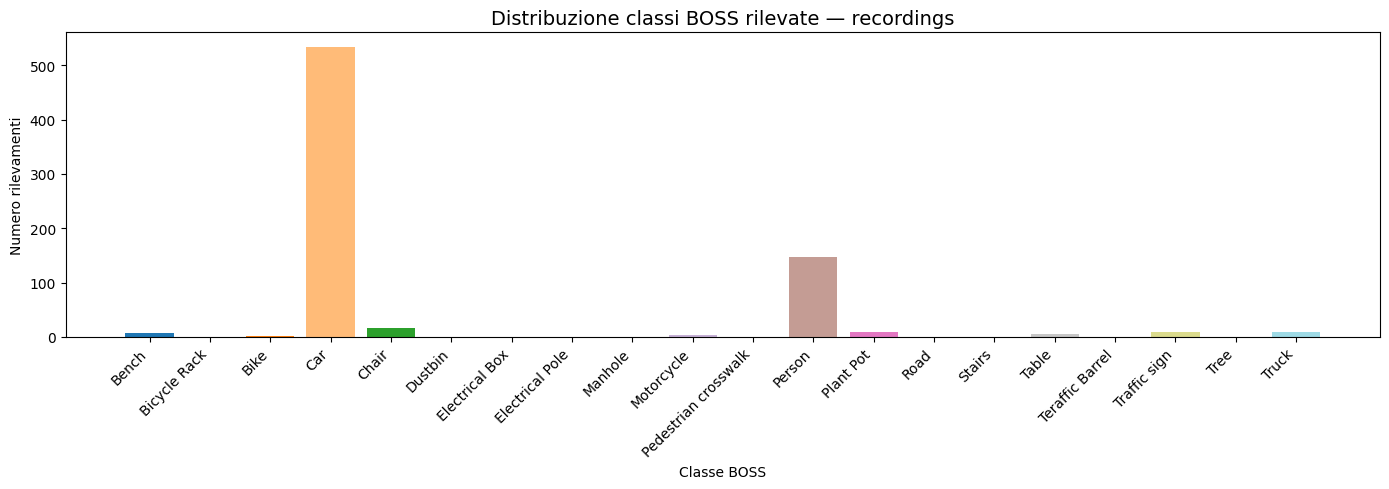

Salvato: /kaggle/working/TEST_OUTPUT/model_output/plot_class_distribution.png


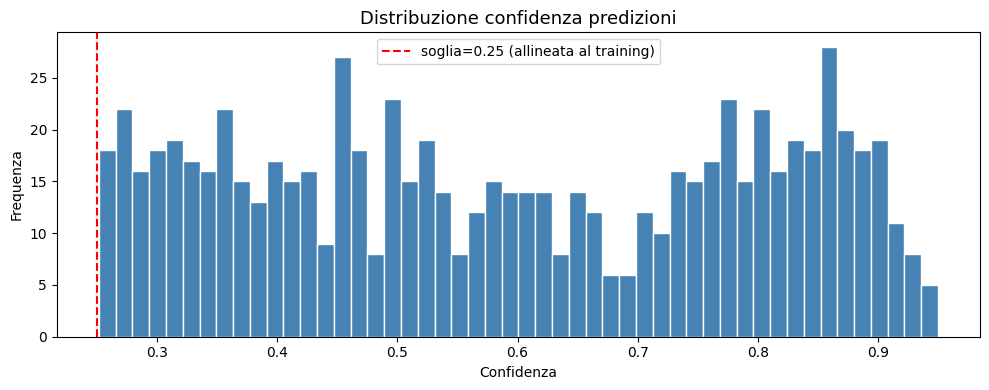

Salvato: /kaggle/working/TEST_OUTPUT/model_output/plot_confidence_distribution.png


In [5]:
# ============================================================
# Cella 5 — Distribuzione classi (BOSS) e confidenza
# ============================================================
# Grafico 1: numero rilevamenti per classe BOSS (predizioni mappate).
# Grafico 2: distribuzione confidenza su tutte le predizioni (istogramma).
# Salvati in TEST_OUTPUT/model_output/.

if df_preds.empty:
    print("Nessuna predizione — grafici saltati.")
else:
    # Grafico 1: rilevamenti per classe BOSS — ordine fisso = BOSS_CLASSES
    df_boss = df_preds.dropna(subset=["boss_class"])
    class_counts = (
        df_boss["boss_class"]
        .value_counts()
        .reindex(BOSS_CLASSES, fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = plt.cm.tab20.colors[:NUM_CLASSES]
    ax.bar(class_counts.index, class_counts.values, color=colors)
    ax.set_title("Distribuzione classi BOSS rilevate — recordings", fontsize=14)
    ax.set_xlabel("Classe BOSS")
    ax.set_ylabel("Numero rilevamenti")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_path = DIR_MODEL_OUT / "plot_class_distribution.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Salvato: {save_path}")

    # Grafico 2: distribuzione confidenza (tutte le predizioni)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df_preds["confidence"], bins=50, color="steelblue", edgecolor="white")
    ax.axvline(
        CONF_THRESHOLD, color="red", linestyle="--",
        label=f"soglia={CONF_THRESHOLD} (allineata al training)"
    )
    ax.set_title("Distribuzione confidenza predizioni", fontsize=13)
    ax.set_xlabel("Confidenza")
    ax.set_ylabel("Frequenza")
    ax.legend()
    plt.tight_layout()
    save_path = DIR_MODEL_OUT / "plot_confidence_distribution.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Salvato: {save_path}")

In [6]:
# ============================================================
# Cella 6 — Preparazione Ground Truth (remap → spazio classi modello)
# ============================================================
# La GT (export Roboflow, già estratta in sola lettura) ha le sue classi in
# data.yaml. Per valutare QUALSIASI modello con val() NATIVO (nessun mismatch
# di nc), le label GT vengono riportate nello spazio ID del modello tramite la
# mappa universale:   gt_id → nome → classe BOSS → model_id
# Le classi BOSS non presenti nel modello vengono scartate dalla GT (il modello
# non può rilevarle → escluse dalla valutazione, niente metriche sfalsate).

gt_root = GT_ZIP_PATH

# Pulisce la prep precedente (ID space diverso tra un modello e l'altro)
gt_test_dir = GT_EXTRACTED / "test"
if gt_test_dir.exists():
    shutil.rmtree(gt_test_dir)

# Legge il data.yaml della GT per ottenere l'ordine classi originale
gt_yaml_in_path = gt_root / "data.yaml"
if not gt_yaml_in_path.exists():
    raise FileNotFoundError(f"data.yaml non trovato in: {gt_yaml_in_path}")
with open(gt_yaml_in_path) as f:
    gt_yaml_in = yaml.safe_load(f)
GT_CLASSES = gt_yaml_in["names"]
print(f"Classi GT ({len(GT_CLASSES)}): {GT_CLASSES}")

# Inverso della mappa modello→BOSS: boss_id → model_id (prima occorrenza)
BOSS_TO_MODEL = {}
for mid, bid in MODEL_TO_BOSS.items():
    BOSS_TO_MODEL.setdefault(bid, mid)

# gt_id → model_id, passando per la classe BOSS canonica (mappa universale)
GT_TO_MODEL = {}
unmapped = []
for gt_id, gt_name in enumerate(GT_CLASSES):
    boss = resolve_to_boss(gt_name)
    if boss is None:
        unmapped.append(gt_name)
        continue
    model_id = BOSS_TO_MODEL.get(BOSS_CLASSES.index(boss))
    if model_id is None:
        unmapped.append(gt_name)
        continue
    GT_TO_MODEL[gt_id] = model_id
print(f"Mappa GT→modello: {GT_TO_MODEL}")
print(f"Classi GT scartate (non rilevabili dal modello): {unmapped}")


def remap_labels(src_label_dir, dst_label_dir, id_map):
    """Copia i file .txt YOLO rimappando i class ID secondo id_map (scarta i non mappati)."""
    src = Path(src_label_dir)
    dst = Path(dst_label_dir)
    dst.mkdir(parents=True, exist_ok=True)
    remapped, dropped = 0, 0
    for lf in src.glob("*.txt"):
        out_lines = []
        for line in lf.read_text().strip().splitlines():
            parts = line.split()
            if not parts:
                continue
            gid = int(parts[0])
            if gid not in id_map:
                dropped += 1
                continue
            parts[0] = str(id_map[gid])
            out_lines.append(" ".join(parts))
            remapped += 1
        (dst / lf.name).write_text("\n".join(out_lines))
    print(f"  Annotazioni rimappate: {remapped} | Righe scartate: {dropped}")


# Lo split 'test' della GT (sola lettura): si collegano (symlink) le immagini
# e si scrivono le label rimappate in /kaggle/working (scrivibile), così
# YOLOv8 trova images/ e labels/ affiancate per la val().
GT_SRC_IMGS    = gt_root      / "test" / "images"
GT_SRC_LABELS  = gt_root      / "test" / "labels"
GT_TEST_IMGS   = GT_EXTRACTED / "test" / "images"
GT_TEST_LABELS = GT_EXTRACTED / "test" / "labels"
if not GT_SRC_IMGS.exists():
    raise FileNotFoundError(f"Cartella immagini test non trovata: {GT_SRC_IMGS}")
GT_TEST_IMGS.mkdir(parents=True, exist_ok=True)

img_count = 0
for ext in ("*.jpg", "*.jpeg", "*.png"):
    for img in GT_SRC_IMGS.glob(ext):
        dst = GT_TEST_IMGS / img.name
        try:
            dst.symlink_to(img.resolve())
        except OSError:
            shutil.copy(img, dst)
        img_count += 1
print(f"Immagini test collegate: {img_count}")

remap_labels(GT_SRC_LABELS, GT_TEST_LABELS, GT_TO_MODEL)

# data.yaml nello spazio classi del MODELLO (val() nativo, nc allineato)
model_names_list = [MODEL_CLASSES[i] for i in range(MODEL_NC)]
gt_data_yaml = {
    "path":  str(GT_EXTRACTED),
    "train": "",
    "val":   "",
    "test":  "test/images",
    "nc":    MODEL_NC,
    "names": model_names_list,
}
gt_yaml_out = GT_EXTRACTED / "data_boss.yaml"
with open(gt_yaml_out, "w") as f:
    yaml.dump(gt_data_yaml, f, default_flow_style=False, allow_unicode=True)
print(f"\ndata_boss.yaml scritto in: {gt_yaml_out}")

Classi GT (20): ['Bench', 'Bicycle Rack', 'Bike', 'Car', 'Chair', 'Dustbin', 'Electrical Box', 'Electrical Pole', 'Manhole', 'Motorcycle', 'Pedestrian crosswalk', 'Person', 'Plant Pot', 'Road', 'Stairs', 'Table', 'Teraffic Barrel', 'Traffic sign', 'Tree', 'Truck']
Mappa GT→modello: {0: 13, 2: 1, 3: 2, 4: 56, 9: 3, 11: 0, 12: 58, 15: 60, 17: 11, 19: 7}
Classi GT scartate (non rilevabili dal modello): ['Bicycle Rack', 'Dustbin', 'Electrical Box', 'Electrical Pole', 'Manhole', 'Pedestrian crosswalk', 'Road', 'Stairs', 'Teraffic Barrel', 'Tree']
Immagini test collegate: 9
  Annotazioni rimappate: 51 | Righe scartate: 22

data_boss.yaml scritto in: /kaggle/working/ground_truth_boss/data_boss.yaml


In [7]:
# ============================================================
# Cella 7 — Valutazione quantitativa contro Ground Truth (Fase B)
# ============================================================
# trained_model.val() confronta le predizioni con le label (già nello spazio
# classi del modello) in ground_truth_boss/test/labels/ e restituisce mAP,
# Precision, Recall. Le metriche aggregate sono mediate solo sulle classi
# BOSS coperte dal modello (le altre non hanno GT → escluse).
# conf=0.001: soglia bassa per integrare tutta la curva PR → mAP corretto.

gt_val_results = trained_model.val(
    data     = str(gt_yaml_out),
    split    = "test",
    imgsz    = IMG_SIZE,
    conf     = 0.001,        # soglia bassa per calcolo mAP corretto (integra tutta la PR curve)
    iou      = IOU_THRESHOLD,
    device   = DEVICE,
    plots    = True,         # genera PR curve e confusion matrix
    project  = str(TEST_OUTPUT),
    name     = "gt_eval",    # → TEST_OUTPUT/gt_eval/
    exist_ok = True,
)

# Metriche aggregate
map50     = gt_val_results.box.map50
map5095   = gt_val_results.box.map
precision = gt_val_results.box.mp
recall    = gt_val_results.box.mr
f1_score  = 2 * (precision * recall) / (precision + recall + 1e-9)

GT_EVAL_SAVE_DIR = Path(gt_val_results.save_dir)  # path esatto per i grafici YOLOv8

print("\n=== Metriche contro Ground Truth (classi BOSS coperte dal modello) ===")
print(f"mAP@0.5:       {map50:.4f}")
print(f"mAP@0.5:0.95:  {map5095:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1_score:.4f}")
print(f"Plot/CM in:    {GT_EVAL_SAVE_DIR}")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.3±3.0 MB/s, size: 90.1 KB)
val: Scanning /kaggle/working/ground_truth_boss/test/labels... 9 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9/9 383.5it/s 0.0s
val: New cache created: /kaggle/working/ground_truth_boss/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all          9         51      0.795      0.803      0.841        0.6
                person          6         13      0.853      0.896      0.902      0.645
                   car          8         38      0.737      0.711      0.781      0.555
Speed: 0.8ms preprocess, 12.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/TEST_OUTPUT/gt_eval

=== Metriche 

=== Metriche per Classe ===
Classe AP@0.5 AP@0.5:0.95 Precision Recall     F1
Person 0.9021      0.6448    0.8532 0.8958 0.8740
   Car 0.7807      0.5546    0.7366 0.7105 0.7233
 MEDIA 0.8414      0.5997    0.7949 0.8032 0.7987

Salvato: /kaggle/working/TEST_OUTPUT/gt_eval/metrics_per_class_gt.csv


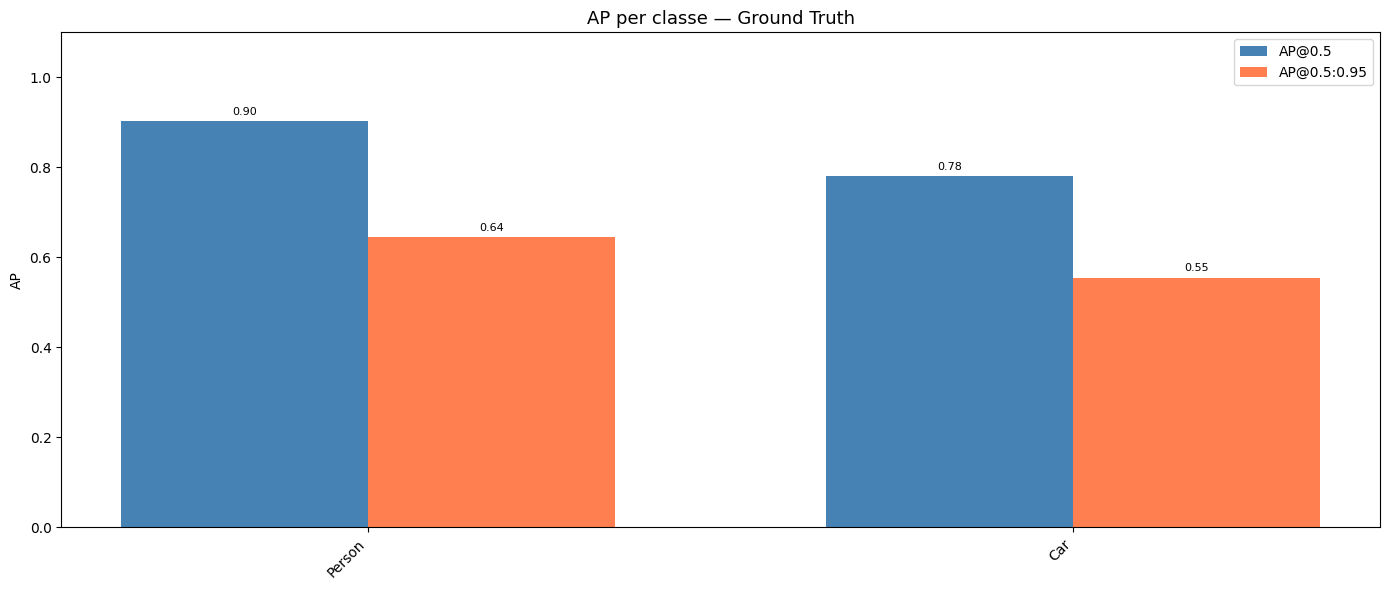

Salvato: /kaggle/working/TEST_OUTPUT/gt_eval/plot_ap_per_class_gt.png


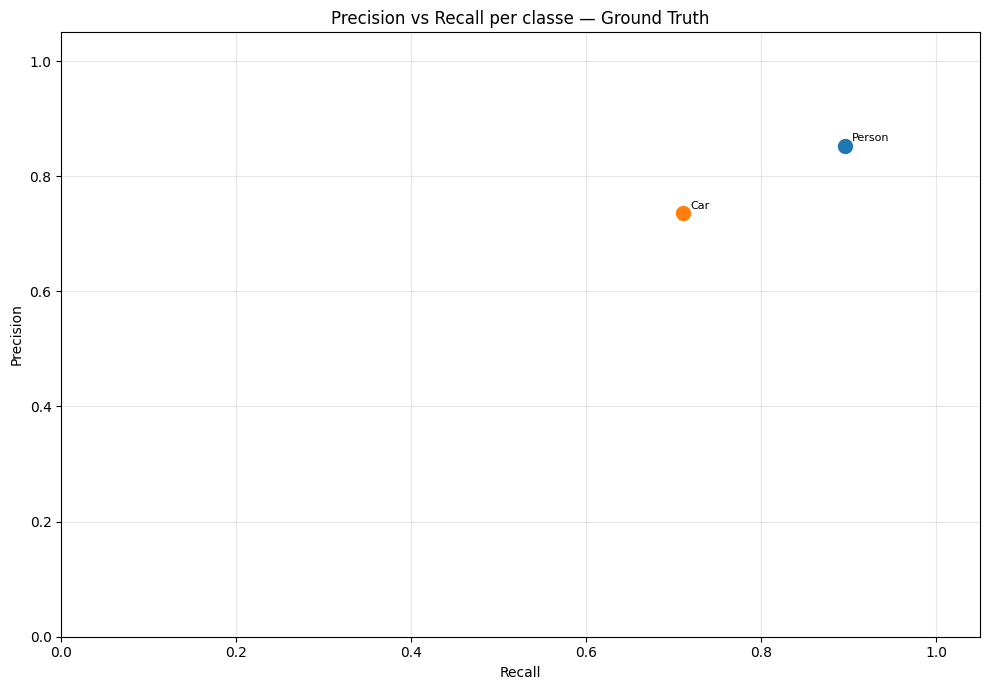

Salvato: /kaggle/working/TEST_OUTPUT/gt_eval/plot_pr_scatter_gt.png


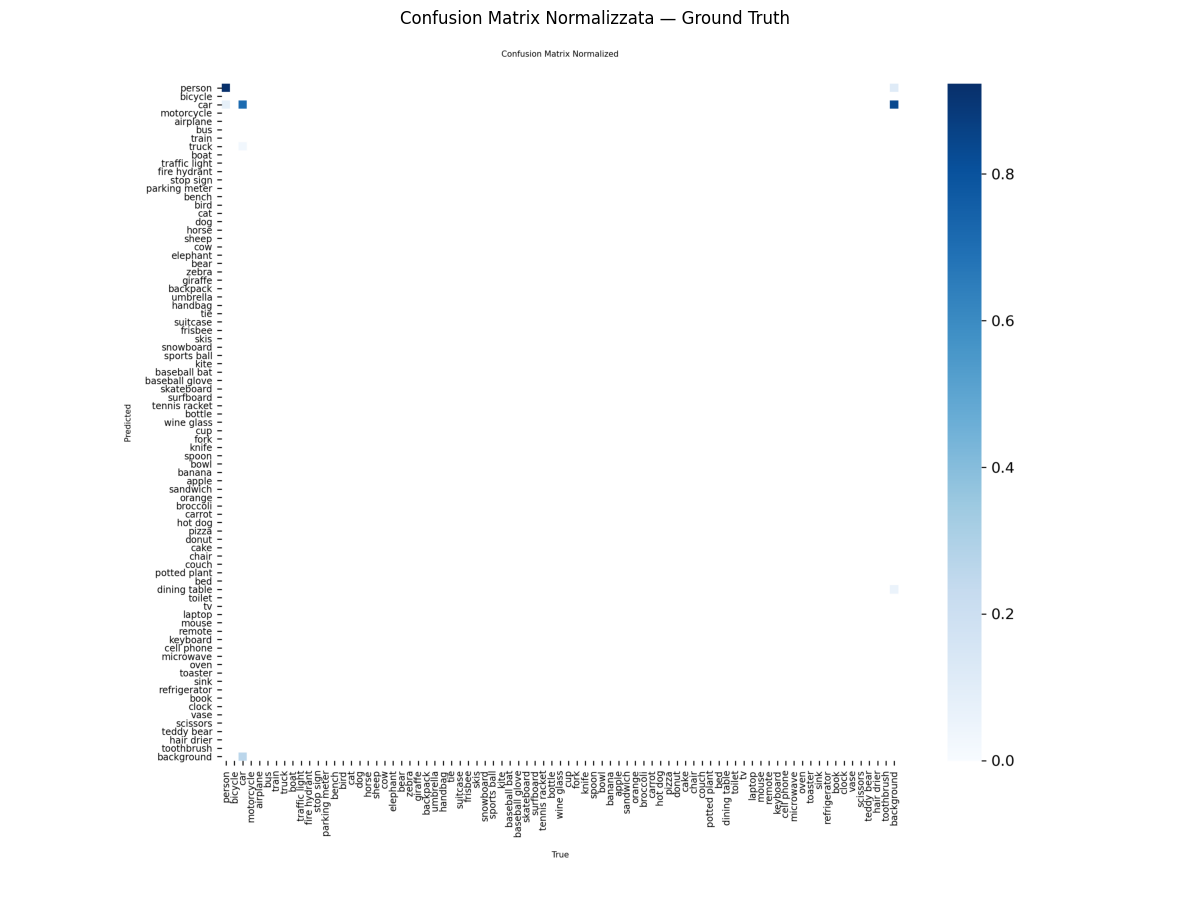

Salvato: /kaggle/working/TEST_OUTPUT/gt_eval/plot_confusion_matrix_gt.png


In [8]:
# ============================================================
# Cella 8 — Metriche per classe + grafici GT
# ============================================================
# Costruisce DataFrame metriche per classe, genera AP bar chart,
# scatter P/R e mostra la confusion matrix prodotta da YOLOv8.
# Salvati in TEST_OUTPUT/gt_eval/.

# Estrae metriche per classe (solo le classi presenti nel test set).
# ap_class_index sono ID nello spazio del modello → etichetta con la classe BOSS.
gt_class_indices = gt_val_results.box.ap_class_index.astype(int)

def _boss_label(model_id):
    bid = MODEL_TO_BOSS.get(int(model_id))
    return BOSS_CLASSES[bid] if bid is not None else MODEL_CLASSES[int(model_id)]

gt_class_names = [_boss_label(i) for i in gt_class_indices]

gt_per_class_ap50   = gt_val_results.box.ap50
gt_per_class_ap5095 = gt_val_results.box.ap
gt_per_class_p      = gt_val_results.box.p
gt_per_class_r      = gt_val_results.box.r
gt_per_class_f1     = 2 * (gt_per_class_p * gt_per_class_r) / (gt_per_class_p + gt_per_class_r + 1e-9)

df_metrics = pd.DataFrame({
    "Classe":      gt_class_names,
    "AP@0.5":      gt_per_class_ap50,
    "AP@0.5:0.95": gt_per_class_ap5095,
    "Precision":   gt_per_class_p,
    "Recall":      gt_per_class_r,
    "F1":          gt_per_class_f1,
})
summary_row = pd.DataFrame([{
    "Classe":      "MEDIA",
    "AP@0.5":      df_metrics["AP@0.5"].mean(),
    "AP@0.5:0.95": df_metrics["AP@0.5:0.95"].mean(),
    "Precision":   df_metrics["Precision"].mean(),
    "Recall":      df_metrics["Recall"].mean(),
    "F1":          df_metrics["F1"].mean(),
}])
df_metrics = pd.concat([df_metrics, summary_row], ignore_index=True)

float_cols = ["AP@0.5", "AP@0.5:0.95", "Precision", "Recall", "F1"]
df_display = df_metrics.copy()
df_display[float_cols] = df_display[float_cols].applymap(lambda x: f"{x:.4f}")
print("=== Metriche per Classe ===")
print(df_display.to_string(index=False))
df_metrics.to_csv(DIR_GT_EVAL / "metrics_per_class_gt.csv", index=False)
print(f"\nSalvato: {DIR_GT_EVAL}/metrics_per_class_gt.csv")

df_plot = df_metrics[df_metrics["Classe"] != "MEDIA"].copy()

# Grafico 1: AP@0.5 e AP@0.5:0.95 per classe
x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, df_plot["AP@0.5"],      width, label="AP@0.5",      color="steelblue")
bars2 = ax.bar(x + width/2, df_plot["AP@0.5:0.95"], width, label="AP@0.5:0.95", color="coral")
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=8)
ax.set_title("AP per classe — Ground Truth", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Classe"], rotation=45, ha="right")
ax.set_ylabel("AP")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
save_path = DIR_GT_EVAL / "plot_ap_per_class_gt.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Salvato: {save_path}")

# Grafico 2: scatter Precision vs Recall per classe
fig, ax = plt.subplots(figsize=(10, 7))
for _, row in df_plot.iterrows():
    ax.scatter(row["Recall"], row["Precision"], s=100, zorder=5)
    ax.annotate(row["Classe"], (row["Recall"], row["Precision"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision vs Recall per classe — Ground Truth")
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_path = DIR_GT_EVAL / "plot_pr_scatter_gt.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Salvato: {save_path}")

# Grafico 3: confusion matrix generata da YOLOv8
cm_path = GT_EVAL_SAVE_DIR / "confusion_matrix_normalized.png"
if cm_path.exists():
    img_cm = Image.open(cm_path)
    plt.figure(figsize=(12, 10))
    plt.imshow(img_cm)
    plt.axis("off")
    plt.title("Confusion Matrix Normalizzata — Ground Truth")
    plt.tight_layout()
    save_path = DIR_GT_EVAL / "plot_confusion_matrix_gt.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Salvato: {save_path}")
else:
    print(f"Confusion matrix non trovata in {cm_path}")

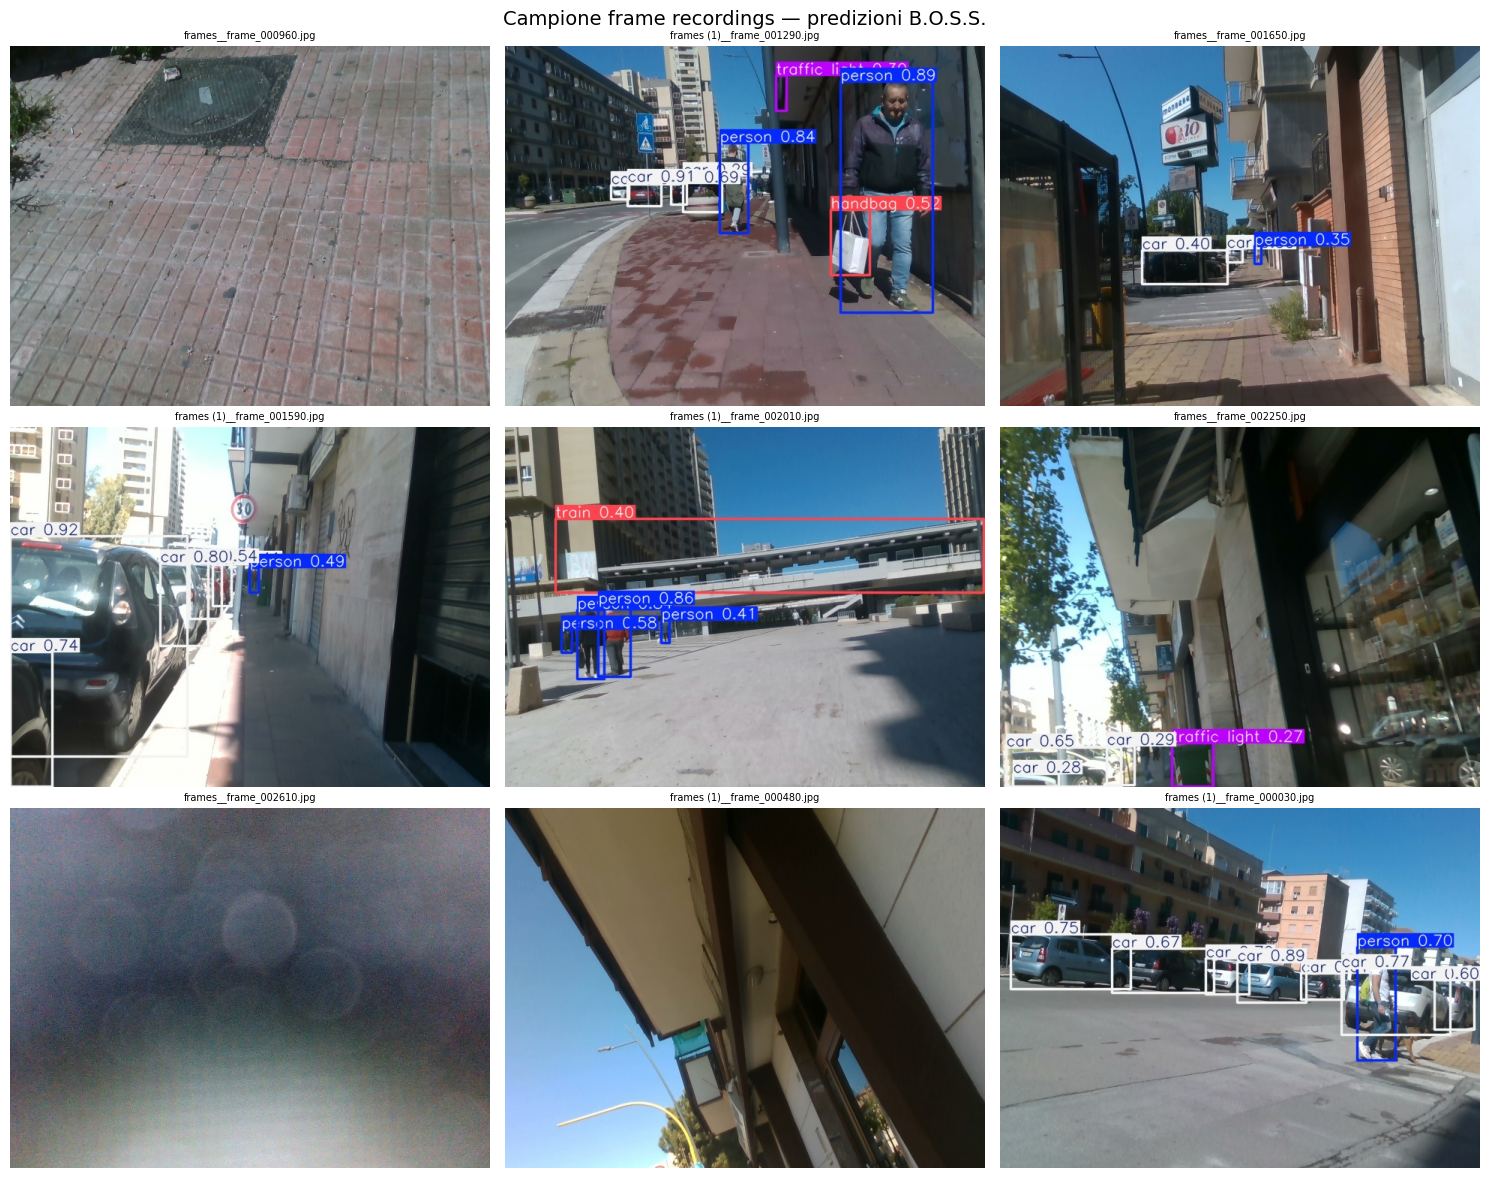

Salvato: /kaggle/working/TEST_OUTPUT/model_output/plot_sample_predictions.png


In [9]:
# ============================================================
# Cella 9 — Griglia campione frame annotati
# ============================================================
# Mostra N_SAMPLES frame con bounding box disegnate da YOLOv8,
# letti da PREDICT_SAVE_DIR (cartella output dell'inferenza).
# Salvata in TEST_OUTPUT/model_output/.

N_SAMPLES = 9

if PREDICT_SAVE_DIR is None or not PREDICT_SAVE_DIR.exists():
    print(f"Cartella inferenza non disponibile: {PREDICT_SAVE_DIR}")
    annotated_imgs = []
else:
    annotated_imgs = (
        list(PREDICT_SAVE_DIR.glob("*.jpg")) +
        list(PREDICT_SAVE_DIR.glob("*.png"))
    )

if len(annotated_imgs) == 0:
    print("Nessun frame annotato disponibile per la griglia.")
else:
    sample = random.sample(annotated_imgs, min(N_SAMPLES, len(annotated_imgs)))
    grid_size = int(np.ceil(np.sqrt(len(sample))))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(5 * grid_size, 4 * grid_size))
    axes_flat = axes.flat if hasattr(axes, "flat") else [axes]

    for ax, img_path in zip(axes_flat, sample):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=7)
        ax.axis("off")
    for ax in list(axes_flat)[len(sample):]:
        ax.axis("off")

    plt.suptitle("Campione frame recordings — predizioni B.O.S.S.", fontsize=14)
    plt.tight_layout()
    save_path = DIR_MODEL_OUT / "plot_sample_predictions.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Salvato: {save_path}")

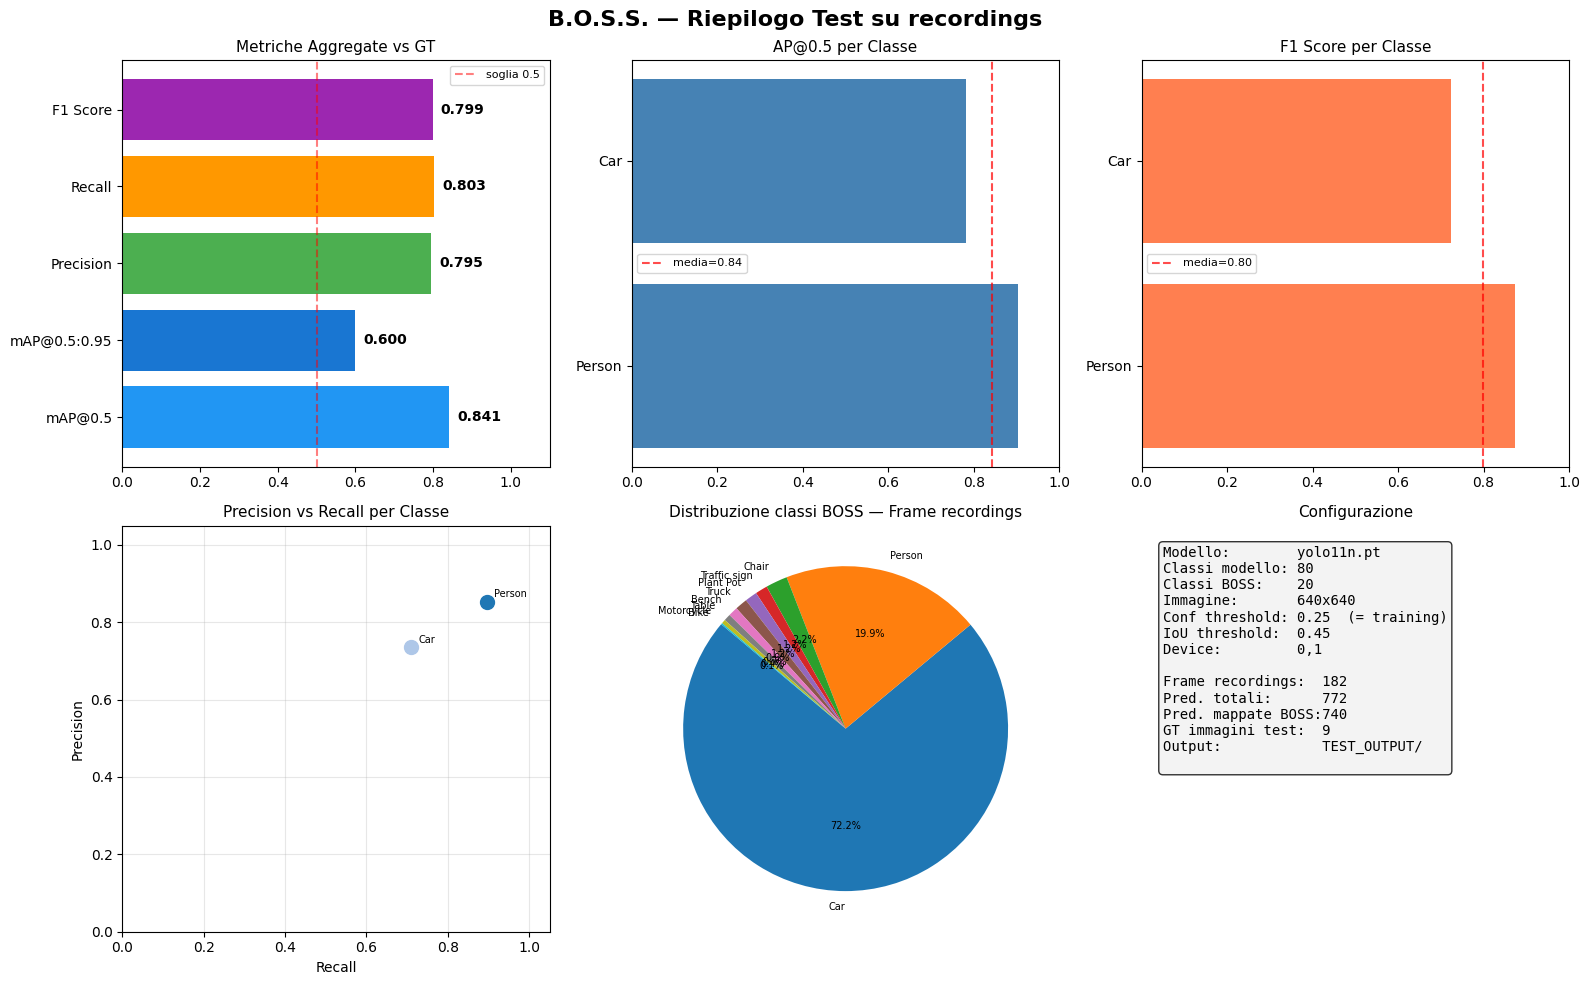

Salvato: /kaggle/working/TEST_OUTPUT/comparison/plot_dashboard_riepilogo.png


In [10]:
# ============================================================
# Cella 10 — Dashboard riepilogo finale (confronto GT vs modello)
# ============================================================
# Dashboard 6-pannelli che combina metriche GT aggregate, AP per classe,
# F1 per classe, scatter P/R, distribuzione classi rilevate e configurazione.
# Salvata in TEST_OUTPUT/comparison/.

fig = plt.figure(figsize=(16, 10))
fig.suptitle("B.O.S.S. — Riepilogo Test su recordings", fontsize=16, fontweight="bold")

# Pannello 1: metriche aggregate GT come barre orizzontali
ax1 = fig.add_subplot(2, 3, 1)
metrics_summary = {
    "mAP@0.5":      map50,
    "mAP@0.5:0.95": map5095,
    "Precision":    precision,
    "Recall":       recall,
    "F1 Score":     f1_score,
}
colors_gauge = ["#2196F3", "#1976D2", "#4CAF50", "#FF9800", "#9C27B0"]
bars_h = ax1.barh(list(metrics_summary.keys()), list(metrics_summary.values()), color=colors_gauge)
for bar, val in zip(bars_h, metrics_summary.values()):
    ax1.text(min(val + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(0, 1.1)
ax1.set_title("Metriche Aggregate vs GT", fontsize=11)
ax1.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="soglia 0.5")
ax1.legend(fontsize=8)

# Pannello 2: AP@0.5 per classe
ax2 = fig.add_subplot(2, 3, 2)
ax2.barh(df_plot["Classe"], df_plot["AP@0.5"], color="steelblue")
ax2.set_title("AP@0.5 per Classe", fontsize=11)
ax2.set_xlim(0, 1)
ax2.axvline(map50, color="red", linestyle="--", alpha=0.7, label=f"media={map50:.2f}")
ax2.legend(fontsize=8)

# Pannello 3: F1 per classe
ax3 = fig.add_subplot(2, 3, 3)
ax3.barh(df_plot["Classe"], df_plot["F1"], color="coral")
ax3.set_title("F1 Score per Classe", fontsize=11)
ax3.set_xlim(0, 1)
ax3.axvline(f1_score, color="red", linestyle="--", alpha=0.7, label=f"media={f1_score:.2f}")
ax3.legend(fontsize=8)

# Pannello 4: scatter Precision vs Recall per classe
ax4 = fig.add_subplot(2, 3, 4)
scatter_colors = plt.cm.tab20.colors[:len(df_plot)]
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax4.scatter(row["Recall"], row["Precision"],
                color=scatter_colors[i % len(scatter_colors)], s=100, zorder=5)
    ax4.annotate(row["Classe"], (row["Recall"], row["Precision"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)
ax4.set_xlabel("Recall")
ax4.set_ylabel("Precision")
ax4.set_title("Precision vs Recall per Classe", fontsize=11)
ax4.set_xlim(0, 1.05)
ax4.set_ylim(0, 1.05)
ax4.grid(True, alpha=0.3)

# Pannello 5: distribuzione classi BOSS rilevate sui frame recordings
ax5 = fig.add_subplot(2, 3, 5)
df_boss5 = df_preds.dropna(subset=["boss_class"]) if not df_preds.empty else df_preds
if not df_preds.empty and not df_boss5.empty:
    class_counts_test = df_boss5["boss_class"].value_counts()
    ax5.pie(class_counts_test.values,
            labels=class_counts_test.index,
            autopct="%1.1f%%",
            startangle=140,
            textprops={"fontsize": 7})
    ax5.set_title("Distribuzione classi BOSS — Frame recordings", fontsize=11)
else:
    ax5.text(0.5, 0.5, "Nessuna predizione mappata", ha="center", va="center")
    ax5.axis("off")

# Pannello 6: info configurazione
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
frames_count = len(all_frames)
pred_count   = len(df_preds)
pred_mapped  = int(df_preds["boss_class"].notna().sum()) if not df_preds.empty else 0
gt_img_count = len(list(GT_TEST_IMGS.glob("*.jpg"))) + len(list(GT_TEST_IMGS.glob("*.png")))
info_text = (
    f"Modello:        {Path(str(MODEL_PATH)).name}\n"
    f"Classi modello: {MODEL_NC}\n"
    f"Classi BOSS:    {NUM_CLASSES}\n"
    f"Immagine:       {IMG_SIZE}x{IMG_SIZE}\n"
    f"Conf threshold: {CONF_THRESHOLD}  (= training)\n"
    f"IoU threshold:  {IOU_THRESHOLD}\n"
    f"Device:         {DEVICE}\n\n"
    f"Frame recordings:  {frames_count}\n"
    f"Pred. totali:      {pred_count}\n"
    f"Pred. mappate BOSS:{pred_mapped}\n"
    f"GT immagini test:  {gt_img_count}\n"
    f"Output:            TEST_OUTPUT/\n"
)
ax6.text(0.05, 0.95, info_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
ax6.set_title("Configurazione", fontsize=11)

plt.tight_layout()
save_path = DIR_COMPARISON / "plot_dashboard_riepilogo.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {save_path}")

In [11]:
# ============================================================
# Cella 11 — Report Markdown (output leggibile da IA)
# ============================================================
# Scrive report .md in TEST_OUTPUT/markdown/: configurazione, metriche
# aggregate vs GT, metriche per classe e distribuzione delle predizioni.

def df_to_md(df):
    """Converte un DataFrame in tabella Markdown, senza dipendenze esterne."""
    cols = list(df.columns)
    head = "| " + " | ".join(str(c) for c in cols) + " |"
    sep  = "| " + " | ".join("---" for _ in cols) + " |"
    rows = []
    for _, r in df.iterrows():
        cells = [f"{r[c]:.4f}" if isinstance(r[c], float) else str(r[c]) for c in cols]
        rows.append("| " + " | ".join(cells) + " |")
    return "\n".join([head, sep] + rows)

gt_img_count = len(list(GT_TEST_IMGS.glob("*.jpg"))) + len(list(GT_TEST_IMGS.glob("*.png")))

if not df_preds.empty:
    class_counts_md = (
        df_preds.dropna(subset=["boss_class"])["boss_class"]
        .value_counts()
        .reindex(BOSS_CLASSES, fill_value=0)
    )
    dist_df = pd.DataFrame({"Classe": class_counts_md.index, "Rilevamenti": class_counts_md.values})
    dist_md = df_to_md(dist_df)
    pred_total       = len(df_preds)
    frames_with_pred = df_preds["frame"].nunique()
else:
    dist_md = "_Nessuna predizione._"
    pred_total = 0
    frames_with_pred = 0

report = f"""# B.O.S.S. — Report Test YOLOv8

## 1. Configurazione
| Parametro | Valore |
| --- | --- |
| Modello | {Path(str(MODEL_PATH)).name} |
| Classi modello | {MODEL_NC} |
| Classi BOSS | {NUM_CLASSES} |
| Dimensione immagine | {IMG_SIZE}x{IMG_SIZE} |
| Conf threshold (inferenza) | {CONF_THRESHOLD} |
| IoU threshold | {IOU_THRESHOLD} |
| Device | {DEVICE} |
| Frame recordings | {len(all_frames)} |
| Immagini GT (test) | {gt_img_count} |

## 2. Metriche aggregate vs Ground Truth
_Mediate sulle classi BOSS coperte dal modello._
| Metrica | Valore |
| --- | --- |
| mAP@0.5 | {map50:.4f} |
| mAP@0.5:0.95 | {map5095:.4f} |
| Precision | {precision:.4f} |
| Recall | {recall:.4f} |
| F1 Score | {f1_score:.4f} |

## 3. Metriche per classe
{df_to_md(df_metrics)}

## 4. Distribuzione predizioni sui recordings
- Predizioni totali: {pred_total}
- Frame con almeno una predizione: {frames_with_pred} / {len(all_frames)}

{dist_md}
"""

report_path = DIR_MARKDOWN / "report.md"
report_path.write_text(report, encoding="utf-8")
print(f"Report Markdown scritto: {report_path}")

metrics_md_path = DIR_MARKDOWN / "metrics_per_class.md"
metrics_md_path.write_text(
    "# Metriche per classe — Ground Truth\n\n" + df_to_md(df_metrics) + "\n",
    encoding="utf-8",
)
print(f"Tabella metriche scritta: {metrics_md_path}")

Report Markdown scritto: /kaggle/working/TEST_OUTPUT/markdown/report.md
Tabella metriche scritta: /kaggle/working/TEST_OUTPUT/markdown/metrics_per_class.md
